# Final combiner round — one label from three sources

Fuses the pipeline on **30 rows of `crumb-legal-qa`** (10 decisive / 10 all_zero / 10 all_tied). One lane on purpose: `gemini_collection` is indexed for this lane, so L2 can actually retrieve; multi-lane would silently degrade L2 or force one Gemini collection per dataset.

```
combined[route] = max(l1[route], l2[route]) + alpha * llm_a[route] + beta * r1[route]
label = argmax(combined),   margin = top - runner
```
- **l1** = bge-small baseline (pool). **l2** = gemini+bm25, scored directly off its indexed collection. `max(l1,l2)` = verified floor.
- **r1** = reranker's per-route score over the union of the routes' top-10s (from the **v3 oracle**, `v3/augmented/oracle/`). **llm_a** = LLM judge (2 calls/row with dense↔sparse order swap): `1.0` on `dense_only`, `sparse_only`, or `pure_rrf` when the swap calls agree with edge ≥ 2, else `1.0` on `pure_rrf` (disagreement / low-edge fallback). Only `parse_failure` on both swap calls is silent.

**Goal:** every row decisive. That's near-automatic under argmax, so the real read is the **trust mix** — measurement vs r1_assisted vs llm_a_only — with margin as the per-row quality gauge. We sweep alpha, beta and take the knee. Verification of a pre-committed fusion, not tuning — single-lane bias is bounded because α/β aren't being *chosen* here.

> Two earlier bugs fixed: the draw now requires **oracle coverage** (native rows are 179k labelled but only ~106k covered), and R1 reads the **v3** oracle (native rows live there, not in the `route_labels`/v2 oracle). Sources are RUN_LIVE-gated; results persist so the sweep re-runs free.

In [27]:
import sys
import pathlib

SRC = pathlib.Path.cwd()
SRC = SRC if (SRC / "scripts").exists() else SRC / "src"
sys.path.insert(0, str(SRC))

import importlib
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from qdrant_client import QdrantClient
from tqdm.auto import tqdm

import scripts.final_combiner as _fc_mod

# Force-reload the pipeline modules so edits take effect without a kernel restart.
import scripts.llm_a_judge as _judge_mod
import scripts.r1_rerank as _r1_mod

importlib.reload(_judge_mod)
importlib.reload(_r1_mod)
importlib.reload(_fc_mod)

from composition.pool_v3 import SCORES, TOL, LabelledPool, native_mask
from hybrid_search_rrf_dataset.fusion import (
    DenseOnlyStrategy,
    PureRRFStrategy,
    SparseOnlyStrategy,
)
from hybrid_search_rrf_dataset.objective import RouterObjective
from hybrid_search_rrf_dataset.router import DATA_DIR, LABELS_PATH
from scripts.final_combiner import ROUTES, attribute, combine, gemini_l2_cost, sweep
from scripts.legb import LEGB_DIR, SPARSE_CFG, LegBPilot, gemini_dense_cfg
from scripts.llm_a_judge import judge_row
from scripts.r1_rerank import r1_route_scores, rerank

# Judge routes onto ROUTES (rrf = judge's "uncertain / disagreement" outcome, first-class).
JUDGE_TO_ROUTE = {"dense": "dense_only", "sparse": "sparse_only", "rrf": "pure_rrf"}

load_dotenv()
client = QdrantClient(url=os.environ["QDRANT_CLOUD_URL"], api_key=os.environ["QDRANT_CLOUD_API_KEY"],
                      timeout=120, cloud_inference=True)
pd.set_option("display.width", 170)

LANE = "crumb-legal-qa"
N_PER = 10
GEMINI_COLLECTION = 'crumb-legal-qa_legb_gemini-embedding-001_routes'
ROWS_PATH = LEGB_DIR / "final_combiner_rows.json"
COST_PATH = LEGB_DIR / "final_combiner_cost.json"  # spend is a property of the run, persisted with it
print("lane:", LANE, "| gemini collection:", GEMINI_COLLECTION)
print("judge model:", _judge_mod.DEFAULT_MODEL, "| rerank model:", _r1_mod.RERANK_MODEL)

lane: crumb-legal-qa | gemini collection: crumb-legal-qa_legb_gemini-embedding-001_routes
judge model: openai/gpt-5.6-luna | rerank model: voyageai/rerank-2.5-lite


In [28]:
augmented_labels = pd.read_parquet(DATA_DIR / 'v3' / 'augmented' / 'labels.parquet')
natural_labels = pd.read_parquet(DATA_DIR / 'v3' / 'labels.parquet')

labels = pd.concat(
    [natural_labels, augmented_labels],
    ignore_index=True,
)
labels = labels[labels["dataset"] == LANE].reset_index(drop=True)

In [29]:
print(labels.shape)
print(labels.head())

(5709, 13)
          dataset query_id       route                                              query  score  score_dense_only  score_pure_rrf  score_sparse_only          shape  \
0  crumb-legal-qa     8712  dense_only  Does the completion of a drug treatment progra...    1.0               1.0             1.0           0.189279  routes_differ   
1  crumb-legal-qa     3858         NaN  Does the law require the landlord to give the ...    0.0               0.0             0.0           0.000000       all_zero   
2  crumb-legal-qa     2986         NaN  Is it specified on what basis it is unlawful t...    0.0               0.0             0.0           0.000000       all_zero   
3  crumb-legal-qa     6424         NaN  Is it required that the evictions summons serv...    0.0               0.0             0.0           0.000000       all_zero   
4  crumb-legal-qa     3473         NaN  Is it specified what protection, if any, the l...    0.0               0.0             0.0           0.000000

## 1. Draw 30 `crumb-legal-qa` rows (dry — no cost)

10 per bucket from the single lane whose corpus is indexed in `gemini_collection`. Bucket derived from the baseline score triple.

In [30]:
all_labels = LabelledPool().classify(LabelledPool().labels())

all_labels

,dataset,query_id,route,score,score_dense_only,score_pure_rrf,score_sparse_only,shape,metric_name,min_relevance,...,margin,depth,winner,kind,route_class,route_class_any,certified,is_decisive,is_hybrid,is_waste
0,antique,3990512,dense_only,0.151267,0.151267,0.075649,0.028669,routes_differ,0.7*HitRate@1+0.3*NDCG@10,3.0,...,0.075618,11.0,dense_only,undecisive,,dense,False,False,False,False
1,antique,714612,dense_only,0.916068,0.916068,0.875791,0.812279,routes_differ,0.7*HitRate@1+0.3*NDCG@10,3.0,...,0.040276,11.0,dense_only,undecisive,,dense,False,False,False,False
2,antique,2528767,dense_only,0.975411,0.975411,0.974202,0.966502,routes_differ,0.7*HitRate@1+0.3*NDCG@10,3.0,...,0.001210,16.0,dense_only,undecisive,,dense,False,False,False,False
3,antique,821387,pure_rrf,0.894942,0.890975,0.894942,0.874184,routes_differ,0.7*HitRate@1+0.3*NDCG@10,3.0,...,0.003967,20.0,pure_rrf,undecisive,,hybrid,False,False,False,False
4,antique,4448097,sparse_only,0.861612,0.852923,0.861612,0.861612,routes_differ,0.7*HitRate@1+0.3*NDCG@10,3.0,...,0.000000,9.0,pure_rrf,undecisive,,hybrid,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225420,crumb-tip-of-the-tongue,356,NaN,0.000000,0.000000,0.000000,0.000000,all_zero,0.7*HitRate@1+0.3*NDCG@10,1.0,...,0.000000,8.0,dense_only,all_zero,,,False,False,False,True
225421,crumb-tip-of-the-tongue,800,pure_rrf,0.929608,0.911175,0.929608,0.901416,routes_differ,0.7*HitRate@1+0.3*NDCG@10,1.0,...,0.018433,3.0,pure_rrf,undecisive,,hybrid,False,False,False,False
225422,crumb-tip-of-the-tongue,263,dense_only,0.037941,0.037941,0.029355,0.000000,routes_differ,0.7*HitRate@1+0.3*NDCG@10,1.0,...,0.008586,8.0,dense_only,undecisive,,dense,False,False,False,False
225423,crumb-tip-of-the-tongue,709,dense_only,0.023519,0.023519,0.000000,0.000000,routes_differ,0.7*HitRate@1+0.3*NDCG@10,1.0,...,0.023519,31.0,dense_only,undecisive,,dense,False,False,False,False


In [31]:
v3ids = set(labels["query_id"])

max_first, min_first = labels[SCORES].max(axis=1), labels[SCORES].min(axis=1)

max_first, min_first

(0       1.000000
 1       0.000000
 2       0.000000
 3       0.000000
 4       0.000000
           ...   
 5704    0.883944
 5705    0.124152
 5706    0.058028
 5707    1.000000
 5708    0.150000
 Length: 5709, dtype: float64,
 0       0.189279
 1       0.000000
 2       0.000000
 3       0.000000
 4       0.000000
           ...   
 5704    0.071159
 5705    0.033916
 5706    0.000000
 5707    0.150000
 5708    0.094639
 Length: 5709, dtype: float64)

In [6]:
labels["bucket"] = np.where(max_first <= TOL, "all_zero", np.where(max_first - min_first <= TOL, "all_tied", "decisive"))

In [7]:
print(labels.columns)

Index(['dataset', 'query_id', 'route', 'query', 'score', 'score_dense_only', 'score_pure_rrf', 'score_sparse_only', 'shape', 'metric_name', 'min_relevance',
       'provenance', 'scored_against', 'bucket'],
      dtype='str')


In [8]:
print(
    "native ∩ covered available per bucket:",
    labels["bucket"].value_counts().to_dict(),
)
print(
    "decisive route mix:",
    labels[labels["bucket"] == "decisive"]["route"].value_counts().to_dict(),
)

per_route = N_PER // 2  # decisive: 5 dense + 5 sparse — pure_rrf is fusion, not a leg
dec_dense = labels[(labels["bucket"] == "decisive") & (labels["route"] == "dense_only")].sample(
    n=per_route, random_state=0
)
dec_sparse = labels[(labels["bucket"] == "decisive") & (labels["route"] == "sparse_only")].sample(
    n=per_route, random_state=0
)
zero = labels[labels["bucket"] == "all_zero"].sample(n=N_PER, random_state=0)
tied = labels[labels["bucket"] == "all_tied"].sample(n=N_PER, random_state=0)

draw = pd.concat([dec_dense, dec_sparse, zero, tied], ignore_index=True)

print(f"drew {len(draw)} rows:", draw["bucket"].value_counts().to_dict())
print(
    "decisive by route:",
    draw[draw["bucket"] == "decisive"]["route"].value_counts().to_dict(),
)

draw[["query_id", "bucket", "query", "route", "dataset"]]

native ∩ covered available per bucket: {'decisive': 3612, 'all_zero': 1930, 'all_tied': 167}
decisive route mix: {'dense_only': 2676, 'sparse_only': 719, 'pure_rrf': 217}
drew 30 rows: {'decisive': 10, 'all_zero': 10, 'all_tied': 10}
decisive by route: {'dense_only': 5, 'sparse_only': 5}


,query_id,bucket,query,route,dataset
0,1776,decisive,Can a landlord evict a tenant for committing d...,dense_only,crumb-legal-qa
1,3864,decisive,Does the law require the landlord to give the ...,dense_only,crumb-legal-qa
2,895,decisive,Can a landlord evict a tenant for committing o...,dense_only,crumb-legal-qa
3,7469,decisive,"For eviction proceedings, does a tenant have t...",dense_only,crumb-legal-qa
4,1338,decisive,Can a landlord evict a tenant for commiting su...,dense_only,crumb-legal-qa
5,aug-corruption-light-385,decisive,Is it specified whether a landlord wÃ¡ives the...,sparse_only,crumb-legal-qa
6,aug-corruption-light-3851,decisive,Does the law require landlords to provide a re...,sparse_only,crumb-legal-qa
7,28,decisive,Is there a state/territory law regulating resi...,sparse_only,crumb-legal-qa
8,6105,decisive,Is it required that the evictions summons serv...,sparse_only,crumb-legal-qa
9,aug-corruption-light-3705,decisive,Is it specified what is required tÃ³ be in the...,sparse_only,crumb-legal-qa


## 2. Run the three sources on the 30 rows — PAID/HEAVY, `RUN_LIVE`-gated

l2 = gemini scored directly off its collection (3 route queries/row); r1 = one rerank/row over the v3-oracle union; llm_a = one LLM call/row. Persists to `ROWS_PATH` so the sweep never re-spends.

In [9]:
_AUG_POOL = None


def _parent_query_id(query_id: str) -> str:
    """Aug rows inherit their parent's qrels; return the parent's query_id
    (or the id unchanged when not augmented)."""
    global _AUG_POOL
    if not query_id.startswith("aug-"):
        return query_id
    if _AUG_POOL is None:
        _AUG_POOL = (
            pd.read_parquet(DATA_DIR / "augmentation" / "pool.parquet")
            [["query_id", "generated_from"]]
            .astype(str)
            .set_index("query_id")
        )
    return _AUG_POOL.loc[query_id, "generated_from"]


def _reads(query_lane: str, query_id: str, queries: pd.DataFrame):
    query_id = str(query_id)

    # Query row (scores stay under the aug id — augmented labels have their own).
    query = queries.loc[
        queries["query_id"].astype(str) == query_id,
        [
            "query_id",
            "score_dense_only",
            "score_pure_rrf",
            "score_sparse_only",
        ],
    ]

    if query.empty:
        raise KeyError(f"query_id={query_id!r} not found in queries")

    query = query.iloc[0]

    # Qrels for this query — aug rows re-key onto the parent's judgments.
    qrels_qid = _parent_query_id(query_id)

    qrels = (
        pd.read_parquet(DATA_DIR / query_lane / "qrels.parquet")
        .astype({"query_id": str, "doc_id": str})
    )

    query_qrels = qrels[qrels["query_id"] == qrels_qid]

    if query_qrels.empty:
        raise KeyError(
            f"No qrels found for query_id={query_id!r} (parent={qrels_qid!r})"
        )

    # Corpus
    corpus = pd.read_parquet(DATA_DIR / query_lane / "corpus.parquet")
    corpus["doc_id"] = corpus["doc_id"].astype(str)

    # Gold documents referenced by qrels
    gold_docs = corpus[
        corpus["doc_id"].isin(query_qrels["doc_id"])
    ].copy()

    # Query-level corpus stats (already keyed on the aug id).
    stats = (
        pd.read_parquet(
            DATA_DIR / "route_labels" / "query_corpus_stats.parquet"
        )
        .astype({"query_id": str})
        .set_index("query_id")
    )

    if query_id not in stats.index:
        raise KeyError(f"No stats found for query_id={query_id!r}")

    query_stats = stats.loc[query_id]

    return query, query_qrels, gold_docs, query_stats

In [10]:
_reads(draw.iloc[0]['dataset'], draw.iloc[0]['query_id'], labels)

(query_id                1776
 score_dense_only     0.09134
 score_pure_rrf           0.0
 score_sparse_only        0.0
 Name: 4439, dtype: object,
       query_id                doc_id  relevance
 12412     1776  1a34f3b4828b77edfe4b          1
 12413     1776  640fd43bdf31156238e1          1
 12414     1776  d99d20c7dfdeab532fb6          1,
                    doc_id title                                               text
 175  d99d20c7dfdeab532fb6        # 2021 Code of Virginia\n## Title 55.1 - Prope...
 177  1a34f3b4828b77edfe4b        # 2021 Code of Virginia\n## Title 55.1 - Prope...
 178  640fd43bdf31156238e1        # 2021 Code of Virginia\n## Title 55.1 - Prope...,
                          dataset   avg_idf   max_idf  oov_share  collection_size  avg_doc_length  vocab_overlap  mean_pmi   min_pmi
 query_id                                                                                                                           
 1776      lotte-technology-forum  0.296660  0.38235

In [11]:
RUN_LIVE = True  # flip to True to spend

if RUN_LIVE:
    strat = {
        "dense_only": DenseOnlyStrategy(
            client,
            GEMINI_COLLECTION,
            gemini_dense_cfg(),
            SPARSE_CFG,
        ),
        "sparse_only": SparseOnlyStrategy(
            client,
            GEMINI_COLLECTION,
            gemini_dense_cfg(),
            SPARSE_CFG,
        ),
        "pure_rrf": PureRRFStrategy(
            client,
            GEMINI_COLLECTION,
            gemini_dense_cfg(),
            SPARSE_CFG,
        ),
    }
else:
    raise RuntimeError("Cannot run now")

In [12]:
cost = {"r1": 0.0, "llm_a": 0.0, "l2": 0.0}  # this-run spend; stays 0 when cached
# PAID run, guarded by ROWS_PATH: skips (no re-spend) when the cache exists, so
# Run All is safe. Delete final_combiner_rows.json to force a fresh, paid run.
if not ROWS_PATH.exists():
    rows = []

    tally = {
        "l2": 0,
        "r1": 0,
        "llm_a": 0,
        "parse_fail": 0,     # judge_row parse_failure on both swap calls
        "rrf": 0,            # judge routes to rrf (disagreement or edge<2)
    }

    # r1/llm_a costs come live from OpenRouter usage; l2 gemini is added after the loop
    # (Qdrant cloud_inference never echoes usage.cost — see the readout cell).
    cost = {"r1": 0.0, "llm_a": 0.0, "l2": 0.0}

    prog = tqdm(
        draw.itertuples(index=False),
        total=len(draw),
        desc="sources: l2 + r1 + llm_a",
    )

    for d in prog:
        qid = str(d.query_id)
        query = str(d.query)
        dataset = str(d.dataset)

        # ------------------------------------------------------------
        # Everything specific to this query
        # ------------------------------------------------------------
        query_row, query_qrels, gold_docs, query_stats = _reads(
            dataset,
            qid,
            labels,
        )

        min_rel = 1

        relevant_qrels = query_qrels[
            query_qrels["relevance"] >= min_rel
        ]

        judged = (
            relevant_qrels["doc_id"]
            .astype(str)
            .tolist()
        )

        gold = {
            doc_id: 1
            for doc_id in judged
        }

        # ------------------------------------------------------------
        # L1 — existing native/oracle scores
        # ------------------------------------------------------------
        l1 = {
            rt: float(query_row[f"score_{rt}"])
            for rt in ROUTES
        }

        # ------------------------------------------------------------
        # L2 — live Gemini retrieval
        #
        # Keep rankings because R1 can reuse their union.
        # ------------------------------------------------------------
        obj = RouterObjective(
            min_relevance=min_rel
        )

        live_rankings = {}
        l2 = {}

        for rt in ROUTES:
            ranking = strat[rt].rank(query)
            live_rankings[rt] = ranking

            l2[rt] = (
                obj.assess(ranking, gold)[0]
                if judged
                else 0.0
            )

        tally["l2"] += 1

        # ------------------------------------------------------------
        # R1 — one reranker call over union of route results
        # ------------------------------------------------------------
        r1v = {
            rt: 0.0
            for rt in ROUTES
        }

        if judged:
            rankings = {
                rt: [
                    str(x.doc_id) if hasattr(x, "doc_id") else str(x)
                    for x in ranking
                ]
                for rt, ranking in live_rankings.items()
            }

            union = sorted(
                set().union(*rankings.values())
                | set(judged)
            )

            # Load only the documents required for this query.
            corpus = pd.read_parquet(
                DATA_DIR / dataset / "corpus.parquet"
            )

            corpus["doc_id"] = (
                corpus["doc_id"]
                .astype(str)
            )

            union_docs = corpus[
                corpus["doc_id"].isin(union)
            ].copy()

            has_title = (
                "title" in union_docs.columns
            )

            doc_text = {
                str(r.doc_id): (
                    f"{r.title}\n{r.text}"
                    if has_title
                    else str(r.text)
                ).strip()
                for r in union_docs.itertuples()
            }

            scores, rerank_usage = rerank(
                query,
                [
                    doc_text.get(doc_id, "")
                    for doc_id in union
                ],
            )
            cost["r1"] += float(rerank_usage.get("cost", 0.0))

            rerank_scores = dict(
                zip(union, scores)
            )

            r1v = r1_route_scores(
                rerank_scores,
                judged,
                rankings,
                min_rel,
            )

            tally["r1"] += 1

            time.sleep(1.0)

        # ------------------------------------------------------------
        # LLM-A — judge_row makes TWO calls with dense/sparse order swapped.
        # Route policy (deterministic): agree + min(edge) >= 2 -> direction,
        # else "rrf" (a first-class outcome, not an abstain). "parse_failure"
        # is the only silent path (both calls malformed after one retry each).
        # ------------------------------------------------------------
        llm_v = {
            rt: 0.0
            for rt in ROUTES
        }

        if judged and not gold_docs.empty:
            relevant_gold_docs = gold_docs[
                gold_docs["doc_id"]
                .astype(str)
                .isin(judged)
            ]

            if not relevant_gold_docs.empty:
                gold_doc = (
                    relevant_gold_docs
                    .iloc[0]
                )

                if (
                    "title" in relevant_gold_docs.columns
                    and pd.notna(gold_doc["title"])
                ):
                    gold_text = (
                        f"{gold_doc['title']}\n"
                        f"{gold_doc['text']}"
                    ).strip()
                else:
                    gold_text = str(
                        gold_doc["text"]
                    ).strip()

                stat_cols = (
                    "avg_idf",
                    "max_idf",
                    "oov_share",
                    "vocab_overlap",
                    "mean_pmi",
                    "collection_size",
                )

                stat_line = ", ".join(
                    f"{col}={query_stats[col]:.3g}"
                    for col in stat_cols
                    if col in query_stats.index
                )

                log = judge_row(query, gold_text[:1200], stat_line)
                cost["llm_a"] += (
                    float(log.call_a_usage.get("cost", 0.0))
                    + float(log.call_b_usage.get("cost", 0.0))
                )

                route_id = JUDGE_TO_ROUTE.get(log.route)   # None on parse_failure
                if route_id is not None:
                    llm_v[route_id] = 1.0

                tally["llm_a"] += 1
                tally["parse_fail"] += int(log.route == "parse_failure")
                tally["rrf"] += int(log.route == "rrf")

        # ------------------------------------------------------------
        # Store this query
        # ------------------------------------------------------------
        rows.append({
            "query_id": qid,
            "dataset": dataset,
            "bucket": d.bucket,
            "query": query,

            "l1": l1,
            "l2": l2,
            "r1": r1v,
            "llm_a": llm_v,
        })

        prog.set_postfix(tally)

    # ------------------------------------------------------------
    # Persist once so later analysis never re-spends
    # ------------------------------------------------------------
    ROWS_PATH.write_text(
        json.dumps(rows)
    )

    print(
        f"ran {len(rows)} rows; "
        f"persisted to {ROWS_PATH.name}"
    )

    # ------------------------------------------------------------
    # Cost readout (dollars). OpenRouter's `usage.cost` is authoritative for r1/llm_a
    # (llm_a = TWO calls/row, dense-first + sparse-first swap). L2 gemini goes through Qdrant
    # cloud_inference, which does not echo usage.cost, so it is ESTIMATED from query tokens
    # (final_combiner.gemini_l2_cost): one embed per dense-bearing route at $0.15/1M. Corpus
    # indexing was the one-time bakeoff pass, amortized over the lane, not charged per label.
    # ------------------------------------------------------------
    cost["l2"] = gemini_l2_cost(rows)
    total = cost["r1"] + cost["llm_a"] + cost["l2"]
    COST_PATH.write_text(json.dumps(cost))  # persist spend so a cached run can still show it
    print(
        f"cost / {len(rows)} rows:  "
        f"r1 rerank ${cost['r1']:.4f}  "
        f"llm_a judge (2 calls/row) ${cost['llm_a']:.4f}  "
        f"l2 gemini ${cost['l2']:.4f} (est., query-side)  "
        f"|  total ${total:.4f}  "
        f"(~${total / len(rows) * 1000:.2f} per 1k rows)"
    )
else:
    print(f"cached: {ROWS_PATH.name} exists — skipping paid run (delete it to force)")
    if COST_PATH.exists():
        cost = json.loads(COST_PATH.read_text())  # restore the real r1/llm_a spend
    else:
        print(f"  (no {COST_PATH.name}: r1/llm_a spend not captured for this cached run — "
              f"delete {ROWS_PATH.name} and re-run once to record it)")

rows = json.loads(ROWS_PATH.read_text())
print(f"{len(rows)} rows available from {ROWS_PATH.name}")


cached: final_combiner_rows.json exists — skipping paid run (delete it to force)
30 rows available from final_combiner_rows.json


In [13]:
print(
    f"ran {len(rows)} rows; "
    f"persisted to {ROWS_PATH.name}"
)

ran 30 rows; persisted to final_combiner_rows.json


In [15]:
# ------------------------------------------------------------
# Cost readout (dollars). OpenRouter's `usage.cost` is authoritative for r1/llm_a.
# L2 gemini goes through Qdrant cloud_inference, which does NOT echo usage.cost — so it is
# ESTIMATED from the query token count (see final_combiner.gemini_l2_cost): each row embeds
# its query once per dense-bearing route (dense_only + pure_rrf) at $0.15/1M tokens. The
# corpus-indexing spend was the one-time bakeoff pass, amortized over the lane, not per-label.
# ------------------------------------------------------------
cost["l2"] = gemini_l2_cost(rows)
total = cost["r1"] + cost["llm_a"] + cost["l2"]
print(
    f"cost / {len(rows)} rows:  "
    f"r1 rerank ${cost['r1']:.4f}  "
    f"llm_a ${cost['llm_a']:.4f}  "
    f"l2 gemini ${cost['l2']:.4f} (est., query-side)  "
    f"|  total ${total:.4f}  "
    f"(~${total / len(rows) * 1000:.2f} per 1k rows)"
)

cost / 30 rows:  r1 rerank $0.0519  llm_a $0.0172  l2 gemini $0.0003 (est., query-side)  |  total $0.0694  (~$2.31 per 1k rows)


## 3. Sweep alpha, beta — decisive vs grounded (free)

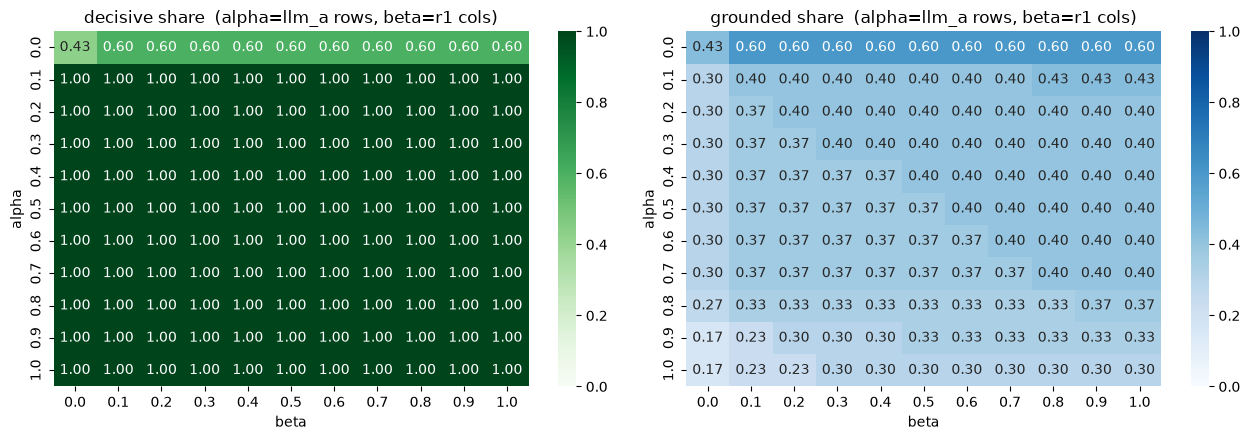

,alpha,beta,decisive,grounded,measurement,r1_assisted,llm_a_only,certifiable,median_margin
0,0.0,0.0,0.433,0.433,0.433,0.000,0.0,0.200,0.000
1,0.0,0.1,0.600,0.600,0.433,0.167,0.0,0.233,0.006
2,0.0,0.2,0.600,0.600,0.433,0.167,0.0,0.233,0.013
3,0.0,0.3,0.600,0.600,0.433,0.167,0.0,0.233,0.019
4,0.0,0.4,0.600,0.600,0.433,0.167,0.0,0.267,0.026
...,...,...,...,...,...,...,...,...,...
116,1.0,0.6,1.000,0.300,0.233,0.067,0.7,0.967,1.000
117,1.0,0.7,1.000,0.300,0.233,0.067,0.7,0.967,1.000
118,1.0,0.8,1.000,0.300,0.233,0.067,0.7,0.967,1.000
119,1.0,0.9,1.000,0.300,0.233,0.067,0.7,0.967,1.000


In [16]:
rows = json.loads(ROWS_PATH.read_text()) if ROWS_PATH.exists() else []
assert rows, "no persisted rows yet — run the RUN_LIVE cell first"

GRID  = [i / 10 for i in range(11)]
table = sweep(rows, GRID, GRID)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, cmap in zip(axes, ["decisive", "grounded"], ["Greens", "Blues"]):
    sns.heatmap(table.pivot(index="alpha", columns="beta", values=col),
                annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{col} share  (alpha=llm_a rows, beta=r1 cols)")
plt.tight_layout(); plt.show()
table.round(3)

## 4. The knee + trust readout

In [24]:
full = table[table["decisive"] >= 1.0]
pick = (full.sort_values(["grounded", "alpha", "beta"], ascending=[False, True, True]).iloc[0]
        if len(full) else table.sort_values("grounded", ascending=False).iloc[0])
A, B = float(pick["alpha"]), float(pick["beta"])
print(f"knee: alpha={A}, beta={B}  ->  decisive {pick['decisive']:.0%}, grounded {pick['grounded']:.0%} "
      f"(measurement {pick['measurement']:.0%} / r1 {pick['r1_assisted']:.0%} / llm_a-only {pick['llm_a_only']:.0%})")

detail = pd.DataFrame([{"query_id": r["query_id"], "bucket": r["bucket"],
                        "winner": combine(r, A, B)[0], "margin": round(combine(r, A, B)[1], 3),
                        "trust": attribute(r, A, B, combine(r, A, B)[0])} for r in rows])
print("\ntrust tier by original bucket:")
print(pd.crosstab(detail["bucket"], detail["trust"]).to_string())
detail.sort_values(["bucket", "trust"]).reset_index(drop=True)

knee: alpha=0.1, beta=0.8  ->  decisive 100%, grounded 43% (measurement 37% / r1 7% / llm_a-only 57%)

trust tier by original bucket:
trust     llm_a_only  measurement  r1_assisted
bucket                                        
all_tied           9            0            1
all_zero           6            4            0
decisive           2            7            1


,query_id,bucket,winner,margin,trust
0,aug-corruption-light-5509,all_tied,sparse_only,0.100,llm_a_only
1,4572,all_tied,pure_rrf,0.100,llm_a_only
2,144,all_tied,pure_rrf,0.100,llm_a_only
3,3447,all_tied,dense_only,0.100,llm_a_only
4,7461,all_tied,dense_only,0.100,llm_a_only
5,6346,all_tied,dense_only,0.100,llm_a_only
6,9277,all_tied,pure_rrf,0.100,llm_a_only
7,5862,all_tied,dense_only,0.100,llm_a_only
8,4331,all_tied,pure_rrf,0.081,llm_a_only
9,7365,all_tied,dense_only,0.154,r1_assisted


In [25]:
# Per-source disagreement (each source's pick in isolation, tie-safe: None on a three-way tie or all-zero).
def _pick(scores: dict) -> str | None:
    top, second = sorted(scores.values(), reverse=True)[:2]
    return None if top <= TOL or top - second <= TOL else max(scores, key=scores.get)


picks = pd.DataFrame([
    {
        "query_id": r["query_id"],
        "bucket": r["bucket"],
        "meas": _pick({rt: max(r["l1"][rt], r["l2"][rt]) for rt in ROUTES}),
        "r1": _pick(r["r1"]),
        "llm_a": _pick(r["llm_a"]),
    }
    for r in rows
])


def _rate(a: str, b: str) -> str:
    both = picks[picks[a].notna() & picks[b].notna()]
    return f"{(both[a] == both[b]).sum()}/{len(both)}" if len(both) else "0/0"


print("pairwise agreement (rows where BOTH picked a route):")
print(f"  meas  vs r1   : {_rate('meas', 'r1')}")
print(f"  meas  vs llm_a: {_rate('meas', 'llm_a')}")
print(f"  r1    vs llm_a: {_rate('r1', 'llm_a')}")


def _pattern(row) -> str:
    valid = {k: row[k] for k in ("meas", "r1", "llm_a") if row[k] is not None}
    if not valid:
        return "all_silent"
    if len(set(valid.values())) == 1:
        return f"agree_{next(iter(valid.values()))} [{'+'.join(sorted(valid))}]"
    speakers = "+".join(sorted(valid))
    return f"disagree [{speakers}]"


picks["pattern"] = picks.apply(_pattern, axis=1)

print("\npattern by bucket:")
print(pd.crosstab(picks["bucket"], picks["pattern"]).to_string())

picks.sort_values(["bucket", "pattern"]).reset_index(drop=True)

pairwise agreement (rows where BOTH picked a route):
  meas  vs r1   : 8/8
  meas  vs llm_a: 5/13
  r1    vs llm_a: 5/13

pattern by bucket:
pattern   agree_dense_only [llm_a+meas+r1]  disagree [llm_a+meas+r1]
bucket                                                              
all_tied                                 0                        10
all_zero                                 2                         8
decisive                                 2                         8


,query_id,bucket,meas,r1,llm_a,pattern
0,aug-corruption-light-5509,all_tied,NaN,NaN,sparse_only,disagree [llm_a+meas+r1]
1,4572,all_tied,NaN,NaN,pure_rrf,disagree [llm_a+meas+r1]
2,144,all_tied,NaN,NaN,pure_rrf,disagree [llm_a+meas+r1]
3,3447,all_tied,NaN,NaN,dense_only,disagree [llm_a+meas+r1]
4,7461,all_tied,NaN,NaN,dense_only,disagree [llm_a+meas+r1]
5,6346,all_tied,NaN,NaN,dense_only,disagree [llm_a+meas+r1]
6,9277,all_tied,NaN,NaN,pure_rrf,disagree [llm_a+meas+r1]
7,7365,all_tied,NaN,dense_only,dense_only,disagree [llm_a+meas+r1]
8,5862,all_tied,NaN,NaN,dense_only,disagree [llm_a+meas+r1]
9,4331,all_tied,NaN,dense_only,pure_rrf,disagree [llm_a+meas+r1]


### Did the job go well? — read the queries

Self-report first (coverage + grounding from the trust tier), then a per-row table you can eyeball: the **query text**, each source's isolated vote (`meas` = argmax of max(l1,l2), `r1`, `llm_a`; `None` = that source was tied/silent), the final `winner`, its `margin`, and `trust` tier. Read the question against the votes — the rows to scrutinise are `llm_a_only` (label rests on the judge alone) and thin margins.

In [26]:
# Per-row inspection: the query text + each source's vote + the final call. Self-contained
# (needs only `rows`, `detail`, A, B from the cells above). `detail` is built from `rows` in
# order, so the list-comprehension columns align positionally.
def _vote(scores):
    """Each source's pick in isolation; None on a tie or all-zero (position is not a decision)."""
    o = sorted(scores.values(), reverse=True)
    return None if o[0] <= TOL or o[0] - o[1] <= TOL else max(scores, key=scores.get)

inspect = detail.copy()  # same row order as `rows`
inspect["query"] = [r["query"] for r in rows]
inspect["meas"] = [_vote({rt: max(r["l1"][rt], r["l2"][rt]) for rt in ROUTES}) for r in rows]
inspect["r1"] = [_vote(r["r1"]) for r in rows]
inspect["llm_a"] = [_vote(r["llm_a"]) for r in rows]

print(f"knee alpha={A}, beta={B}  ({len(inspect)} rows)")
print(f"  coverage (decisive label): {inspect['winner'].notna().mean():.0%}")
print(f"  grounded (measurement/r1): {inspect['trust'].isin(['measurement', 'r1_assisted']).mean():.0%}")
print(f"  opinion-only (llm_a):      {(inspect['trust'] == 'llm_a_only').mean():.0%}")

cols = ["bucket", "query", "meas", "r1", "llm_a", "winner", "margin", "trust"]
with pd.option_context("display.max_colwidth", 80, "display.width", 240):
    print("\n" + inspect[cols].sort_values(["bucket", "trust"]).reset_index(drop=True).to_string())
inspect[cols]

knee alpha=0.1, beta=0.8  (30 rows)
  coverage (decisive label): 100%
  grounded (measurement/r1): 43%
  opinion-only (llm_a):      57%

      bucket                                                                                                                                                                                                                                                                                                                         query         meas           r1        llm_a       winner  margin        trust
0   all_tied                                                                                                             Secondary methods of service are defined as those methods that may be used if the primary method is unsÃºccessful. Is mail a permitted secondary method of service for an eviction action? In the state of Kansas          NaN          NaN  sparse_only  sparse_only   0.100   llm_a_only
1   all_tied                                           

,bucket,query,meas,r1,llm_a,winner,margin,trust
0,decisive,Can a landlord evict a tenant for committing d...,dense_only,NaN,pure_rrf,pure_rrf,0.053,llm_a_only
1,decisive,Does the law require the landlord to give the ...,dense_only,dense_only,pure_rrf,dense_only,0.006,measurement
2,decisive,Can a landlord evict a tenant for committing o...,dense_only,NaN,sparse_only,dense_only,0.073,measurement
3,decisive,"For eviction proceedings, does a tenant have t...",dense_only,dense_only,dense_only,dense_only,1.591,measurement
4,decisive,Can a landlord evict a tenant for commiting su...,dense_only,dense_only,pure_rrf,dense_only,1.362,measurement
5,decisive,Is it specified whether a landlord wÃ¡ives the...,dense_only,dense_only,dense_only,dense_only,1.559,measurement
6,decisive,Does the law require landlords to provide a re...,dense_only,NaN,dense_only,dense_only,0.128,measurement
7,decisive,Is there a state/territory law regulating resi...,NaN,dense_only,pure_rrf,pure_rrf,0.179,r1_assisted
8,decisive,Is it required that the evictions summons serv...,NaN,pure_rrf,dense_only,dense_only,0.051,llm_a_only
9,decisive,Is it specified what is required tÃ³ be in the...,sparse_only,sparse_only,dense_only,sparse_only,0.623,measurement


## Reading it

- **Goal** met wherever `decisive` reads 1.00. The real read is `grounded` + the trust crosstab: high `measurement`/`r1_assisted`, low `llm_a_only` = labels resting on retrieval evidence.
- **By bucket:** decisive rows should be `measurement`; all_tied should break via `r1_assisted`; all_zero is where `llm_a_only` concentrates — the least trustworthy, and the honest limit of what this round grounds.
- **`gate`-style caveats:** certifiable margin (≥ 0.1) flags a trustworthy decisive vs a hair-thin one; r1 uses the provisional `min(judged)` floor (upper bound); 30 rows on one lane is directional, not a verdict.


## 5. r1 truncation probe — what does 40k buy over 4k?

r1 is ~75% of surfaced cost and `MAX_DOCUMENT_CHARS` is its only knob. This reranks each row's union at 4k and 40k chars and compares (a) cost and (b) whether r1's *winning route* changes. If the pick agrees on every row, 40k is paying for tokens that move no label. PAID / RUN_LIVE-gated; persists to disk so the readout re-reads free.

In [19]:
# r1 truncation probe: rerank each row's union at 4k and 40k chars, compare cost + winning route.
# PAID (reranks len(draw) rows x 2 caps). Reuses the same strat/_reads as the main run.
R1_PROBE_PATH = LEGB_DIR / "r1_truncation_probe.json"
PROBE_CAPS = (4_000, 40_000)


def _r1_pick(scores):
    """r1's winning route, or None on a three-way tie / all-zero (position is not a decision)."""
    ordered = sorted(scores, key=scores.get, reverse=True)
    if scores[ordered[0]] <= TOL or scores[ordered[0]] - scores[ordered[1]] <= TOL:
        return None
    return ordered[0]


RUN_LIVE_PROBE = True  # flip to spend

if RUN_LIVE_PROBE and not R1_PROBE_PATH.exists():
    corpus_cache = {}
    probe = []
    for d in tqdm(draw.itertuples(index=False), total=len(draw), desc="r1 probe 4k vs 40k"):
        qid, query, dataset = str(d.query_id), str(d.query), str(d.dataset)
        _, query_qrels, _, _ = _reads(dataset, qid, labels)
        judged = query_qrels[query_qrels["relevance"] >= 1]["doc_id"].astype(str).tolist()
        if not judged:
            continue
        rankings = {rt: [str(x.doc_id) if hasattr(x, "doc_id") else str(x)
                         for x in strat[rt].rank(query)] for rt in ROUTES}
        union = sorted(set().union(*rankings.values()) | set(judged))
        if dataset not in corpus_cache:
            c = pd.read_parquet(DATA_DIR / dataset / "corpus.parquet")
            c["doc_id"] = c["doc_id"].astype(str)
            corpus_cache[dataset] = c
        udocs = corpus_cache[dataset][corpus_cache[dataset]["doc_id"].isin(union)]
        has_title = "title" in udocs.columns
        doc_text = {str(r.doc_id): (f"{r.title}\n{r.text}" if has_title else str(r.text)).strip()
                    for r in udocs.itertuples()}
        docs = [doc_text.get(x, "") for x in union]
        rec = {"query_id": qid, "bucket": d.bucket, "n_docs": len(union),
               "union_chars": sum(len(x) for x in docs)}
        for cap in PROBE_CAPS:
            sc, usage = rerank(query, docs, max_chars=cap)
            r1v = r1_route_scores(dict(zip(union, sc)), judged, rankings, 1)
            rec[f"cost_{cap}"] = float(usage.get("cost", 0.0))
            rec[f"pick_{cap}"] = _r1_pick(r1v)
            time.sleep(1.0)
        probe.append(rec)
    R1_PROBE_PATH.write_text(json.dumps(probe))
    print(f"probed {len(probe)} rows -> {R1_PROBE_PATH.name}")
else:
    why = "cached: " + R1_PROBE_PATH.name if R1_PROBE_PATH.exists() else "RUN_LIVE_PROBE is False"
    print(f"{why} — skipping paid probe (delete the file / flip the flag to spend).")

r1 probe 4k vs 40k: 100%|██████████| 30/30 [02:55<00:00,  5.85s/it]

probed 30 rows -> r1_truncation_probe.json


In [ ]:
probe = json.loads(R1_PROBE_PATH.read_text()) if R1_PROBE_PATH.exists() else []
assert probe, "no probe yet — run the RUN_LIVE_PROBE cell above"
pf = pd.DataFrame(probe)
lo, hi = PROBE_CAPS

cost_lo, cost_hi = pf[f"cost_{lo}"].sum(), pf[f"cost_{hi}"].sum()
# None (r1 tie/silent) must compare equal to None — pandas NaN != NaN would otherwise
# count a both-silent row as "changed", wildly understating agreement.
pick_lo, pick_hi = pf[f"pick_{lo}"].fillna("(tie)"), pf[f"pick_{hi}"].fillna("(tie)")
agree = (pick_lo == pick_hi).mean()
changed = pf[pick_lo != pick_hi]

if cost_hi:
    print(f"cost @ {lo // 1000}k: ${cost_lo:.4f}   @ {hi // 1000}k: ${cost_hi:.4f}   "
          f"savings: ${cost_hi - cost_lo:.4f} ({(1 - cost_lo / cost_hi) * 100:.0f}% cheaper at {lo // 1000}k)")
print(f"per 1k rows: ${cost_lo / len(pf) * 1000:.2f} @ {lo // 1000}k  vs  "
      f"${cost_hi / len(pf) * 1000:.2f} @ {hi // 1000}k")
print(f"r1 winning-route agreement: {agree:.0%} ({len(pf) - len(changed)}/{len(pf)} rows unchanged)")
print(f"docs/row: {pf['n_docs'].mean():.0f} mean, {pf['n_docs'].max()} max   "
      f"union chars/row: {pf['union_chars'].mean():.0f} mean, {pf['union_chars'].max():,} max")

if len(changed):
    print("\nrows where the 4k pick differs from 40k (what truncation costs in labels):")
    print(changed[["query_id", "bucket", f"pick_{lo}", f"pick_{hi}", "n_docs", "union_chars"]]
          .to_string(index=False))
else:
    print("\nno row changed its r1 winning route — 40k paid for tokens that moved no label.")
pf